# EDA

## 1. Preparación de los datos

In [1]:
# Importación de Librerías
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud

%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 8.0]

In [3]:
# Configuración inicial 
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo de fondo
sns.set_style("whitegrid")

# Paleta global: Set3 (12 colores)
sns.set_palette("Set3")

# Opcional: definir tamaño de fuente y contexto general
sns.set_context("notebook", font_scale=1.2)



En primer lugar, se realiza la carga del dataset y un análisis descriptivo inicial de su contenido, con el fin de comprender la estructura de los datos, sus variables y principales características.

In [22]:
#Datos Tabulares
df = pd.read_csv('../input/petfinder-adoption-prediction/train/train.csv')


In [23]:
# Dimensiones del DataFrame
print(f"El dataframe tiene {df.shape[0]:,} filas y {df.shape[1]} columnas.")

# Observamos los primeros registros con head
df.drop('Description', axis=1).head()


El dataframe tiene 14,993 filas y 24 columnas.


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,850a43f90,3.0,2


### 1.1. Variables

* PetID - Unique hash ID of pet profile
* AdoptionSpeed - Categorical speed of adoption. Lower is faster. This is the value to predict. See below section for more info.
* Type - Type of animal (1 = Dog, 2 = Cat)
* Name - Name of pet (Empty if not named)
* Age - Age of pet when listed, in months
* Breed1 - Primary breed of pet (Refer to BreedLabels dictionary)
* Breed2 - Secondary breed of pet, if pet is of mixed breed (Refer to BreedLabels dictionary)
* Gender - Gender of pet (1 = Male, 2 = Female, 3 = Mixed, if profile represents group of pets)
* Color1 - Color 1 of pet (Refer to ColorLabels dictionary)
* Color2 - Color 2 of pet (Refer to ColorLabels dictionary)
* Color3 - Color 3 of pet (Refer to ColorLabels dictionary)
* MaturitySize - Size at maturity (1 = Small, 2 = Medium, 3 = Large, 4 = Extra Large, 0 = Not Specified)
* FurLength - Fur length (1 = Short, 2 = Medium, 3 = Long, 0 = Not Specified)
* Vaccinated - Pet has been vaccinated (1 = Yes, 2 = No, 3 = Not Sure)
* Dewormed - Pet has been dewormed (1 = Yes, 2 = No, 3 = Not Sure)
* Sterilized - Pet has been spayed / neutered (1 = Yes, 2 = No, 3 = Not Sure)
* Health - Health Condition (1 = Healthy, 2 = Minor Injury, 3 = Serious Injury, 0 = Not Specified)
* Quantity - Number of pets represented in profile
* Fee - Adoption fee (0 = Free)
* State - State location in Malaysia (Refer to StateLabels dictionary)
* RescuerID - Unique hash ID of rescuer
* VideoAmt - Total uploaded videos for this pet
* PhotoAmt - Total uploaded photos for this pet
* Description - Profile write-up for this pet. The primary language used is English, with some in Malay or Chinese.

### 1.2 Pre-Procesamiento

In [25]:
# Resumen general del dataset

def resumen_dataset(df):
    print("Resumen del Dataset")
    print("-"*40)
    print(f"Total de filas: {df.shape[0]}")
    print(f"Total de columnas: {df.shape[1]}\n")
    
    print("Nombres de columnas:")
    print(df.columns.tolist(), "\n")
    
    print("Tipos de datos:")
    print(df.dtypes, "\n")
    
    

# ---- Uso ----
resumen_dataset(df)


Resumen del Dataset
----------------------------------------
Total de filas: 14993
Total de columnas: 24

Nombres de columnas:
['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID', 'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed'] 

Tipos de datos:
Type               int64
Name              object
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID         object
VideoAmt           int64
Description       object
PetID             object
PhotoAmt         float64
AdoptionSpe

### 1.3 Revisión y análisis de Nulos

In [26]:
# Resumen de Nulos 

total_registros = len(df)
print(f" Total de registros: {total_registros}\n")

# Calcular totales
nulos = df.isnull().sum()
no_nulos = df.notnull().sum()
nulos_pct = (nulos / total_registros) * 100

# Armar dataframe ordenado
nulos_df = pd.DataFrame({
    "Total Registros": total_registros,
    "Datos No Nulos": no_nulos,
    "Datos Nulos": nulos,
    "% Nulos": nulos_pct.round(2)
}).sort_values(by="Datos Nulos", ascending=False)

# Mostrar solo columnas con al menos 1 nulo
nulos_df = nulos_df[nulos_df["Datos Nulos"] > 0]

if nulos_df.empty:
    print("No hay valores nulos en el dataset.")
else:
    print("Valores nulos por columna:\n")
    display(nulos_df)


 Total de registros: 14993

Valores nulos por columna:



,Total Registros,Datos No Nulos,Datos Nulos,% Nulos
Name,14993,13728,1265,8.44
Description,14993,14980,13,0.09


Los valores nulos se presentan únicamente en las variables Name y Description. Se considera relevante conservarlos, ya que la ausencia de estos datos podría aportar información valiosa para el análisis.

### 1.4 Análisis de Variables Categóricas

In [27]:
cat_list = ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3',
            'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized',
            'Health', 'State', 'AdoptionSpeed' ]

In [28]:
# Resumen de variables categóricas

cat_summary = pd.DataFrame({
    "Variable": cat_list,
    "Cantidad de Categorías": [df[col].nunique() for col in cat_list],
    "Categorías": [df[col].unique().tolist() for col in cat_list]
})

display(cat_summary)


,Variable,Cantidad de Categorías,Categorías
0,Type,2,"[2, 1]"
1,Breed1,176,"[299, 265, 307, 266, 264, 218, 114, 285, 189, ..."
2,Breed2,135,"[0, 264, 205, 307, 117, 251, 265, 218, 292, 26..."
3,Gender,3,"[1, 2, 3]"
4,Color1,7,"[1, 2, 5, 6, 3, 7, 4]"
5,Color2,7,"[7, 2, 0, 6, 5, 4, 3]"
6,Color3,6,"[0, 7, 5, 6, 4, 3]"
7,MaturitySize,4,"[1, 2, 3, 4]"
8,FurLength,3,"[1, 2, 3]"
9,Vaccinated,3,"[2, 3, 1]"


In [29]:
# Resumen de categorías: Perros vs Gatos

resumen = []

for category in cat_list:
    # Perros
    df_perros = df[df["Type"] == 1]
    n_perros = df_perros[category].nunique()
    vals_perros = df_perros[category].unique().tolist()
    
    # Gatos
    df_gatos = df[df["Type"] == 2]
    n_gatos = df_gatos[category].nunique()
    vals_gatos = df_gatos[category].unique().tolist()
    
    resumen.append({
        "Variable": category,
        "Perros (categorías únicas)": n_perros,
        "Valores Perros": vals_perros,
        "Gatos (categorías únicas)": n_gatos,
        "Valores Gatos": vals_gatos
    })

resumen_df = pd.DataFrame(resumen)
display(resumen_df)



,Variable,Perros (categorías únicas),Valores Perros,Gatos (categorías únicas),Valores Gatos
0,Type,1,[1],1,[2]
1,Breed1,116,"[307, 218, 189, 205, 128, 213, 141, 173, 207, ...",68,"[299, 265, 266, 264, 114, 285, 292, 243, 250, ..."
2,Breed2,84,"[0, 205, 307, 117, 218, 141, 128, 96, 76, 169,...",55,"[0, 264, 251, 265, 292, 266, 285, 306, 303, 24..."
3,Gender,3,"[1, 2, 3]",3,"[1, 2, 3]"
4,Color1,7,"[2, 1, 6, 5, 7, 3, 4]",7,"[1, 5, 6, 2, 3, 7, 4]"
5,Color2,7,"[7, 2, 0, 5, 3, 6, 4]",7,"[7, 2, 6, 0, 4, 3, 5]"
6,Color3,6,"[0, 7, 6, 4, 3, 5]",6,"[0, 5, 7, 6, 4, 3]"
7,MaturitySize,4,"[2, 3, 1, 4]",4,"[1, 2, 3, 4]"
8,FurLength,3,"[2, 1, 3]",3,"[1, 2, 3]"
9,Vaccinated,3,"[1, 2, 3]",3,"[2, 3, 1]"


### 1.4 Recodificación de la variable Tipo (Type)

Para facilitar la interpretación de los resultados, se transformaron los códigos en etiquetas descriptivas: 
- Valor es 1: Dog
- Cat

## 2. Análisis Exploratorio de Datos

### Análisis cuantitativo

In [35]:
#Instanciamos un df para cada tipo, para no tener que aplicar filtro todo el tiempo.

df_dog = df[df['Type'] == "Dog"]
df_cat = df[df['Type'] == "Cat"]

### 2.1 Edad

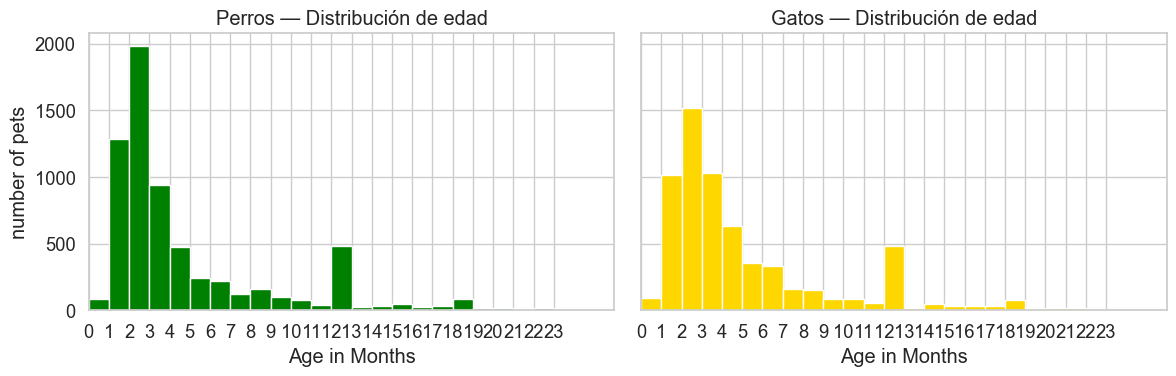

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Bins de 0 a 24 meses cada 1
bins = np.arange(0, 24, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Perros
axes[0].hist(df_dog["Age"].dropna(), bins=bins, color="green", edgecolor="white")
axes[0].set_title("Perros — Distribución de edad")
axes[0].set_xlabel("Age in Months")
axes[0].set_ylabel("number of pets")
axes[0].set_xticks(bins)
axes[0].set_xlim(0, 26)

# Gatos
axes[1].hist(df_cat["Age"].dropna(), bins=bins, color="gold", edgecolor="white")
axes[1].set_title("Gatos — Distribución de edad")
axes[1].set_xlabel("Age in Months")
axes[1].set_xticks(bins)
axes[1].set_xlim(0, 26)

plt.tight_layout()
plt.show()


La distribución se concentra en edades tempranas: la mayoría de los animales tiene entre 2 y 3 meses, y a partir de ahí la cantidad cae rápidamente a medida que la edad aumenta (tanto en perros como en gatos)

### 2.2. Costo de adopción (fee)

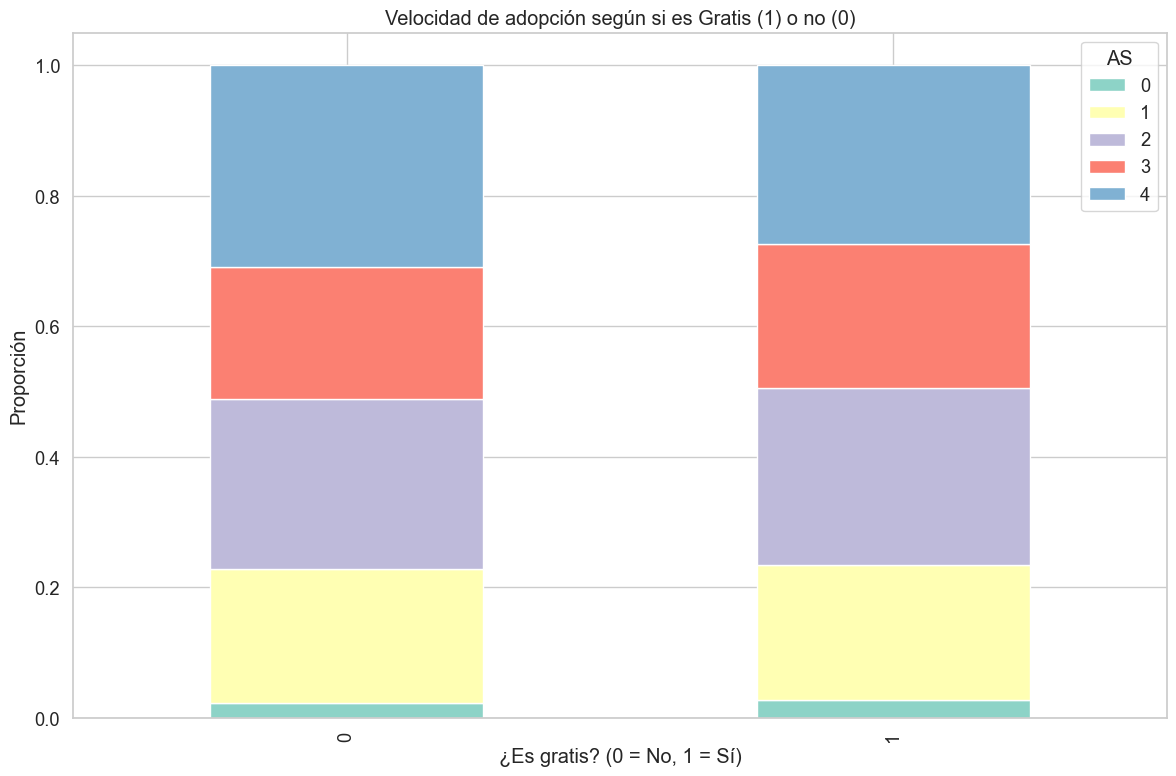

In [38]:
df["Gratis"] = df["Fee"].apply(lambda x: 1 if x == 0 else 0)
# Paso 1: contar por Gratis y AdoptionSpeed
counts = df.groupby(['Gratis', 'AdoptionSpeed']).size().unstack(fill_value=0)

# Paso 2: calcular proporciones por fila (cada barra suma 1)
proportions = counts.div(counts.sum(axis=1), axis=0)

# Paso 3: graficar barras apiladas con Puro en el eje X y segmentos por AdoptionSpeed
proportions.plot(kind='bar', stacked=True)

plt.title('Velocidad de adopción según si es Gratis (1) o no (0)')
plt.xlabel('Estado')
plt.xlabel("¿Es gratis? (0 = No, 1 = Sí)")
plt.ylabel('Proporción')
plt.legend(title='AS', loc='upper right')
plt.tight_layout()
plt.show()

El gráfico muestra que la velocidad de adopción es prácticamente la misma, tanto para las mascotas gratuitas como para las que tienen costo.

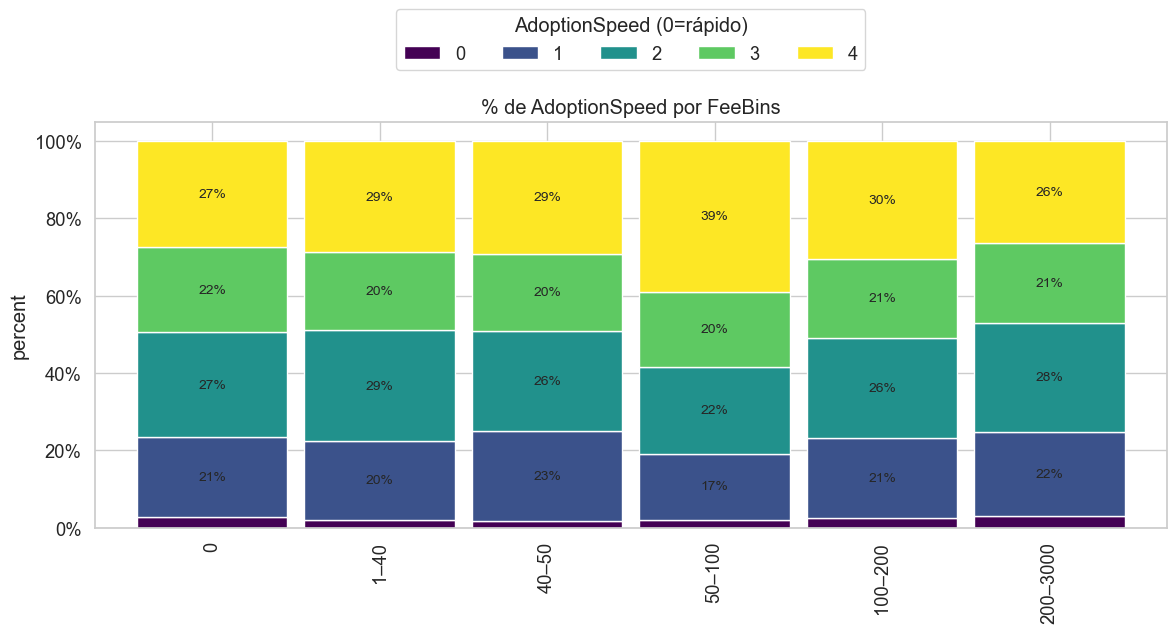

    FeeBins      n
0         0  12663
1      1–40    483
2     40–50    471
3    50–100    516
4   100–200    437
5  200–3000    423


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil
from matplotlib.ticker import PercentFormatter

# 1) Bin de Fee
def make_fee_bins(df, fee_col="Fee", m=500, out_col="FeeBins"):
    fees = pd.to_numeric(df[fee_col], errors="coerce")
    is_zero = fees.eq(0)
    pos = fees[~is_zero & fees.notna()]
    k = max(1, ceil(len(pos) / m))
    cats_pos = pd.qcut(pos, q=k, duplicates="drop")

    bins = pd.Series(index=df.index, dtype="object")
    bins[is_zero] = "0"
    bins.loc[cats_pos.index] = cats_pos.astype(str)

    cats_order = ["0"] + [str(iv) for iv in cats_pos.cat.categories]
    df[out_col] = pd.Categorical(bins, categories=cats_order, ordered=True)
    return df

# 2) (Opcional) Reordenar y renombrar categorías
def reorder_rename_bins(df, bins_col="FeeBins"):
    old_order  = ["0", "(0.999, 40.0]", "(40.0, 50.0]", "(50.0, 100.0]",
                  "(100.0, 200.0]", "(200.0, 3000.0]"]
    new_labels = ["0", "1–40", "40–50", "50–100", "100–200", "200–3000"]
    df[bins_col] = df[bins_col].cat.reorder_categories(old_order, ordered=True)
    df[bins_col] = df[bins_col].cat.rename_categories(dict(zip(old_order, new_labels)))
    return df

# 3) Gráfico y tablas
def plot_as_by_fee_bins(df, bins_col="FeeBins", as_col="AdoptionSpeed", label_threshold=0.04):
    order_speed = [0, 1, 2, 3, 4]
    AS = pd.to_numeric(df[as_col], errors="coerce")
    AS = pd.Categorical(AS, categories=order_speed, ordered=True)

    ct = pd.crosstab(df[bins_col], AS, dropna=False).reindex(
        index=list(df[bins_col].cat.categories), columns=order_speed, fill_value=0
    )
    props = (ct.T / ct.sum(axis=1)).T.fillna(0)

    fig, ax = plt.subplots(figsize=(12, 8))
    props.plot(kind="bar", stacked=True, ax=ax, width=0.9, edgecolor="white", colormap="viridis")
    ax.set_title("% de AdoptionSpeed por FeeBins")
    ax.set_xlabel("")
    ax.set_ylabel("percent")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(title="AdoptionSpeed (0=rápido)", ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.30))

    for i, bin_name in enumerate(props.index):
        cum = 0
        for s in order_speed:
            v = props.loc[bin_name, s]
            if v > label_threshold:
                ax.text(i, cum + v/2, f"{v*100:.0f}%", ha="center", va="center", fontsize=10)
            cum += v

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

    # ---- Tablas devueltas ----
    counts = (ct.stack()
                .rename("n")
                .reset_index()
                .rename(columns={"row_0": bins_col, "col_0": as_col}))

    # Totales por rango de bins
    totales_bins = counts.groupby(bins_col)["n"].sum().reset_index()

    # Ordenar según el orden vigente de categorías
    orden_bins = list(df[bins_col].cat.categories)
    totales_bins[bins_col] = pd.Categorical(totales_bins[bins_col],
                                            categories=orden_bins, ordered=True)
    totales_bins = totales_bins.sort_values(bins_col).reset_index(drop=True)

    return counts, totales_bins

# ----------------- Uso -----------------
df = make_fee_bins(df, fee_col="Fee", m=500, out_col="FeeBins")
df = reorder_rename_bins(df, bins_col="FeeBins")  # opcional

counts, totales_bins = plot_as_by_fee_bins(df, bins_col="FeeBins", as_col="AdoptionSpeed")
print(totales_bins)



El monto de la tarifa no parece estar fuertemente ligado a la velocidad de adopción; solo se observa e nota una pequeña demora en el rango de 50–100.

### Análisis cualitativo

#### 2.3 Distribución: Proporción según tipo de mascota

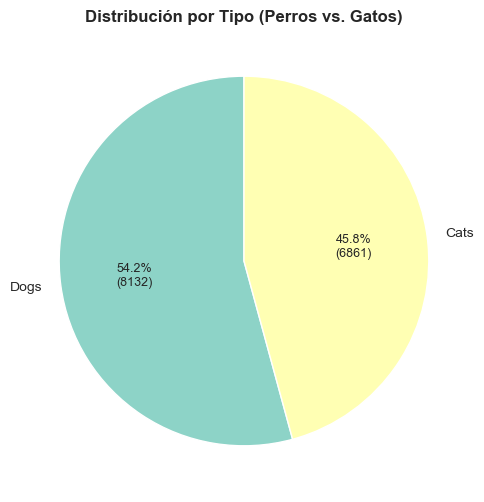

In [40]:
labels = ["Dogs", "Cats"]

count_dogs = df[df["Type"]=="Dog"].shape[0]
count_cats = df[df["Type"]=="Cat"].shape[0]

sizes = [count_dogs, count_cats]

# Tamaño de la figura reducido
fig, ax = plt.subplots(figsize=(6, 6))

# Gráfico de torta con % automático
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(sizes)/100)})',
    startangle=90
)

# Mejorar estilo
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)

ax.set_title("Distribución por Tipo (Perros vs. Gatos)", fontsize=12, fontweight="bold")
plt.show()



Se registra una mayor proporción de perros (54,2%) respecto de gatos (45,8%), lo que indica una leve mayoría de perros.

### 2.4 Velocidad de adopción según tipo

#### 2.4.1 Variable: AdoptionSpeed

El valor indica la rapidez con la que una mascota fue adoptada (o si no fue adoptada). La codificación es la siguiente:

* 0 → La mascota fue adoptada el mismo día en que fue publicada.
* 1 → La mascota fue adoptada entre 1 y 7 días (1.ª semana) después de ser publicada.
* 2 → La mascota fue adoptada entre 8 y 30 días (1.er mes) después de ser publicada.
* 3 → La mascota fue adoptada entre 31 y 90 días (2.º y 3.er mes) después de ser publicada.
* 4 → La mascota no fue adoptada después de 100 días de haber sido publicada.

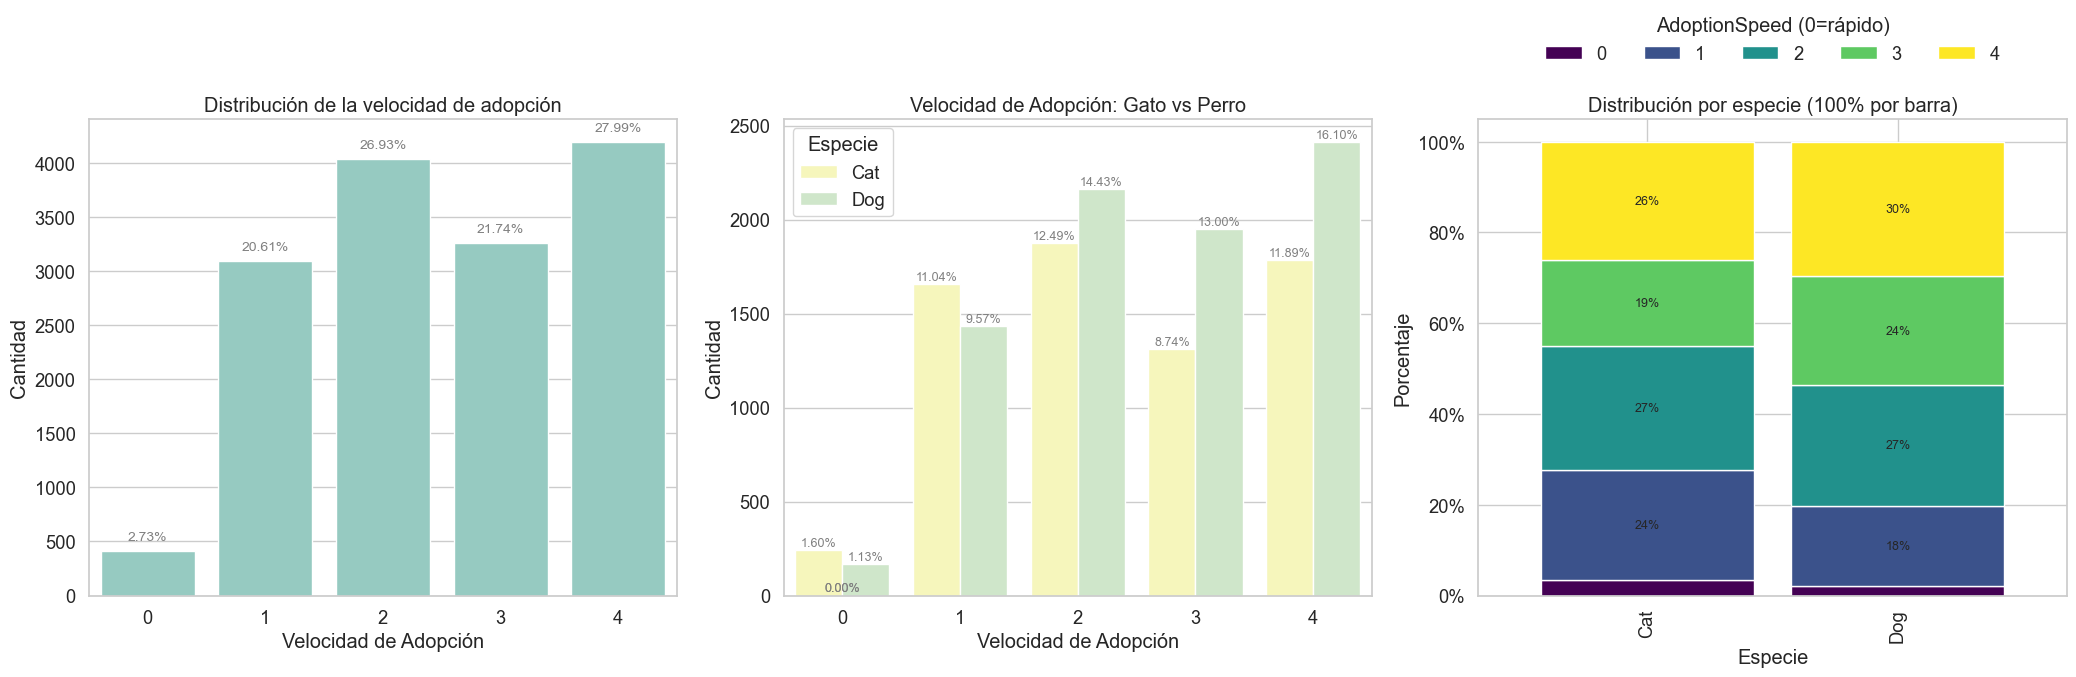

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# --- Opcional: normalizar etiquetas de especie a "Cat"/"Dog"
df_plot = df.copy()
if set(df_plot['Type'].unique()) <= {0, 1}:
    df_plot['TypeLabel'] = np.where(df_plot['Type'] == 1, 'Dog', 'Cat')
else:
    df_plot['TypeLabel'] = df_plot['Type']

# Orden consistente
order_speed = [0, 1, 2, 3, 4]
species_order = ["Cat", "Dog"]

# Crear figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

# ---------- 1) Countplot general con porcentajes ----------
sns.countplot(x='AdoptionSpeed', data=df_plot, ax=axes[0], order=order_speed)
axes[0].set_title('Distribución de la velocidad de adopción')
axes[0].set_xlabel('Velocidad de Adopción')
axes[0].set_ylabel('Cantidad')

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height() * 100 / len(df_plot):.2f}%",
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='center', fontsize=10, color='gray',
                     xytext=(0, 10), textcoords='offset points')

# ---------- 2) Countplot por especie con porcentajes ----------
sns.countplot(x='AdoptionSpeed', data=df_plot, hue='TypeLabel',
              ax=axes[1], order=order_speed,
              palette={'Cat': '#ffffb3', 'Dog': '#ccebc5'})
axes[1].set_title('Velocidad de Adopción: Gato vs Perro')
axes[1].set_xlabel('Velocidad de Adopción')
axes[1].set_ylabel('Cantidad')
axes[1].legend(title='Especie')

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height() * 100 / len(df_plot):.2f}%",
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='center', fontsize=9, color='gray',
                     xytext=(0, 5), textcoords='offset points')

# ---------- 3) 100% apilado por especie ----------
as_num = pd.to_numeric(df_plot["AdoptionSpeed"], errors="coerce")
tab = (pd.crosstab(df_plot["TypeLabel"], as_num)
         .reindex(index=species_order, columns=order_speed, fill_value=0))
props = tab.div(tab.sum(axis=1), axis=0).fillna(0)

props.plot(kind="bar", stacked=True, ax=axes[2], width=0.85,
           edgecolor="white", colormap="viridis")

axes[2].set_title("Distribución por especie (100% por barra)")
axes[2].set_xlabel("Especie")
axes[2].set_ylabel("Porcentaje")
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))
leg = axes[2].legend(title="AdoptionSpeed (0=rápido)", ncol=5,
                     loc="upper center", bbox_to_anchor=(0.5, 1.25),
                     frameon=False)

# Etiquetas internas (≥5% para evitar ruido)
for i, specie in enumerate(props.index):
    cum = 0
    for s in order_speed:
        v = props.loc[specie, s]
        if v >= 0.05:
            axes[2].text(i, cum + v/2, f"{v*100:.0f}%",
                         ha="center", va="center", fontsize=9)
        cum += v

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


La adopción inmediata (0) es poco común. Cerca de la mitad de las mascotas se adopta dentro del primer mes (1–2). 

Por especie, los gatos suelen adoptarse más rápido, mientras que los perros aparecen con más frecuencia en esperas prolongadas, lo que sugiere mayor dificultad promedio para conseguir adoptante.

### 2.5 Análisis según Raza

Analizando el dataset, se puede se puede definir que las razas son "impuras" si:
* Breed2 distinto de 0 → significa que están registradas con dos razas, por lo tanto son mestizas.
* Breed1 == 307 → corresponde al identificador de “Mixed”, que ya indica explícitamente que no es de raza pura.

Para poder diferenciarlos se crea una nueva columna llamada Puro con valores:
* 1 → raza pura
* 0 → impuro (mestizo)

In [42]:
df["Puro"] = np.where((df["Breed2"] > 0) | (df["Breed1"] == 307), 0, 1)

Analizamos si hay algun animal sin raza:

In [43]:
#Cantidad de puros
print(f"Hay {len(df[df["Puro"]==1])} puros")

# Vemos si hay alguno con Breed1 ==0, lo cual no deberia
print(f"Sin raza 1: {len(df[(df["Breed1"] == 0)])}")

# Vemos si hay con 0 en ambos
print(f"Sin ambas: {len(df[(df["Breed1"] == 0) & (df["Breed2"] == 0)])}")

Hay 6227 puros
Sin raza 1: 5
Sin ambas: 0


En el dataset se identificaron 6.227 mascotas de raza pura (41,5% del total). Se detectaron 5 registros con Breed1 = 0, considerados inconsistentes por no tener asignada una raza principal. No se hallaron casos con ambas razas en cero, por lo que no existen mascotas sin información de raza.

In [44]:
len(df[(df["Breed1"] == 307) & (df["Breed2"] == 0)])

4535

Dentro del dataset se identificaron 4.535 mascotas registradas como mestizos/impursos, lo que equivale al 30,2% del total de observaciones.

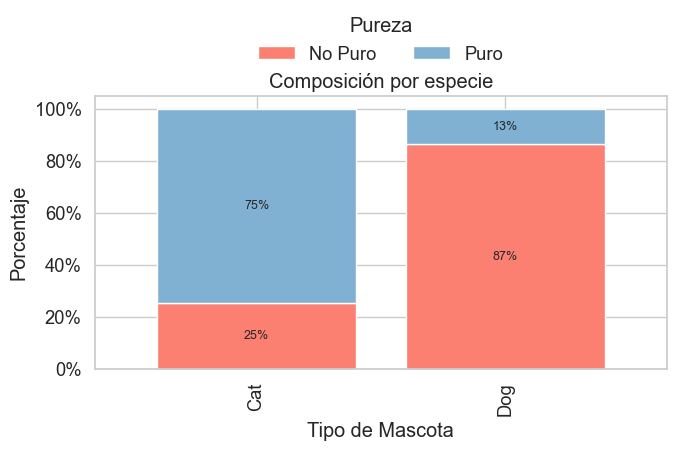

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- Crosstab por especie (Type) y pureza (Puro) ---
# Aseguramos columnas en orden [No Puro (0), Puro (1)]
conteo = (pd.crosstab(df["Type"], df["Puro"])
            .reindex(columns=[0, 1], fill_value=0))

# Renombrar columnas para la leyenda/etiquetas
conteo.columns = ["No Puro", "Puro"]

# Proporciones por especie (cada fila suma 1)
props = conteo.div(conteo.sum(axis=1), axis=0)

# --- Plot 100% apilado ---
fig, ax = plt.subplots(figsize=(7, 6))
props.plot(kind="bar", stacked=True, ax=ax, width=0.8, edgecolor="white",
           color=["#fb8072", "#80b1d3"])

ax.set_title("Composición por especie")
ax.set_xlabel("Tipo de Mascota")
ax.set_ylabel("Porcentaje")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="Pureza", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.35), frameon=False)

# Etiquetas de porcentaje dentro de cada segmento (>= 5% para evitar ruido)
for i, especie in enumerate(props.index):
    cum = 0
    for col in props.columns:
        v = props.loc[especie, col]
        if v >= 0.05:
            ax.text(i, cum + v/2, f"{v*100:.0f}%", ha="center", va="center", fontsize=9)
        cum += v

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()





Se observa que, según la clasificación, los gatos presentan una proporción significativamente mayor de ejemplares de raza pura en comparación con los perros.

A continuación, se analiza cómo se distribuyen ambos grupos según la variable AdoptionSpeed.

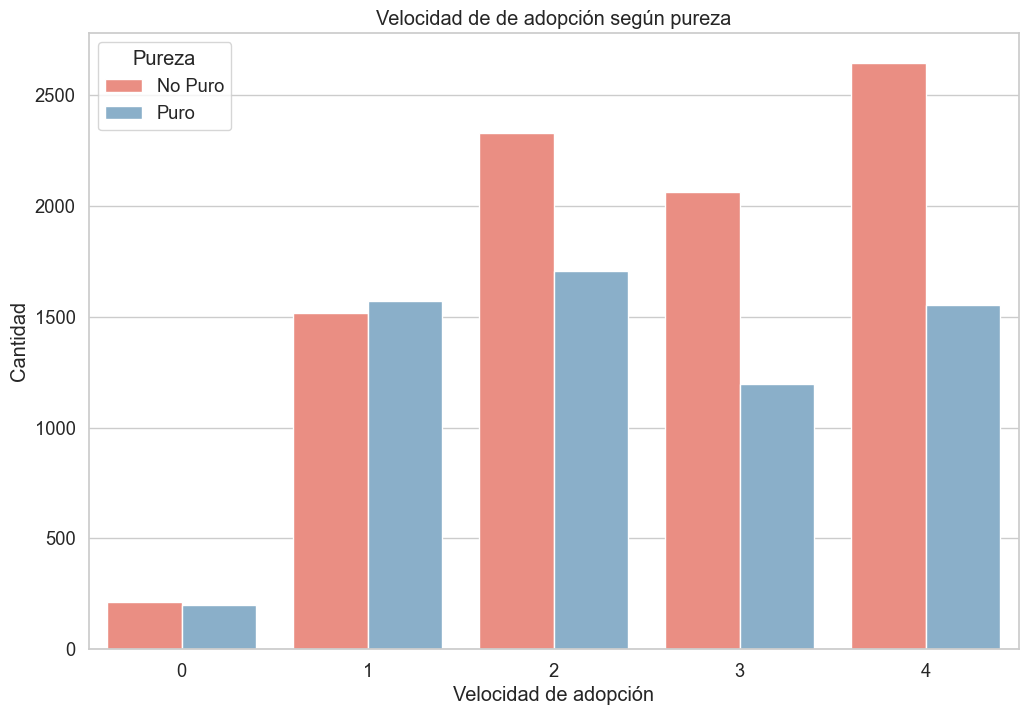

In [46]:
# Definir colores consistentes con el gráfico anterior
colors_pureza = {0: "#fb8072", 1: "#80b1d3"}  # 0 = No puro, 1 = Puro

sns.countplot(
    x='AdoptionSpeed',
    data=df,
    hue='Puro',
    palette=colors_pureza
)

plt.title('Velocidad de de adopción según pureza')
plt.xlabel('Velocidad de adopción')
plt.ylabel('Cantidad')
plt.legend(title="Pureza", labels=["No Puro", "Puro"])
plt.show()


El análisis muestra que la pureza de raza influye en la velocidad de adopción. Las mascotas de raza pura presentan una ligera ventaja en las adopciones rápidas durante la primera semana, mientras que las no puras predominan en los plazos más largos (categorías 2, 3 y 4), lo que refleja una mayor demora o incluso ausencia de adopción.

Preparación de subconjuntos de datos

In [48]:
#Instanciamos un df para cada tipo, para no tener que aplicar filtro todo el tiempo.

df_dog = df[df['Type'] == "Dog"]
df_cat = df[df['Type'] == "Cat"]

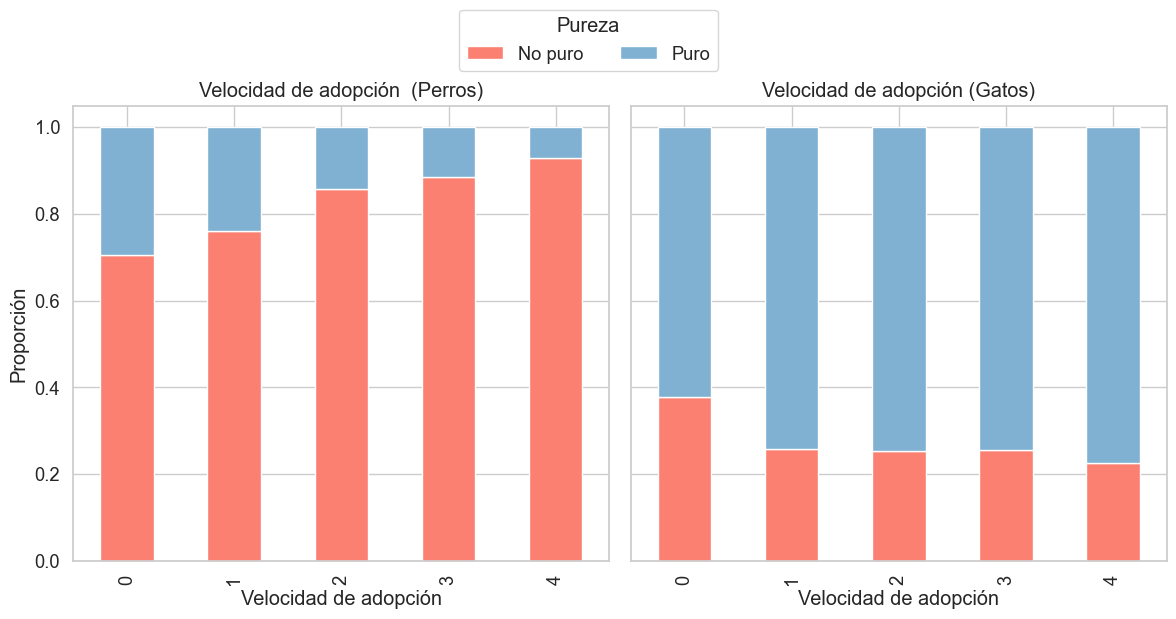

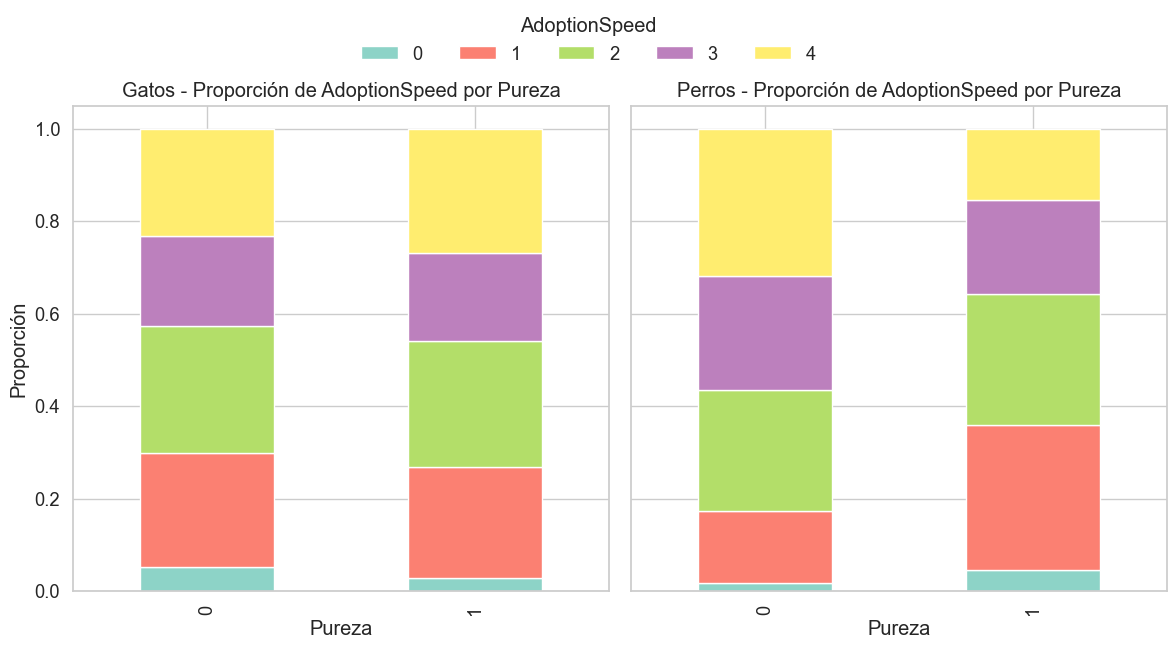

In [49]:
#Segmentacion por tipo y pureza
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Perros ---
counts_dog = df_dog.groupby(['AdoptionSpeed', 'Puro']).size().unstack(fill_value=0)
proportions_dog = counts_dog.div(counts_dog.sum(axis=1), axis=0)

proportions_dog.plot(
    kind='bar', 
    stacked=True, 
    color=[colors_pureza[0], colors_pureza[1]], 
    ax=axes[0]
)
axes[0].legend_.remove()
axes[0].set_title('Velocidad de adopción  (Perros)')
axes[0].set_xlabel('Velocidad de adopción')
axes[0].set_ylabel('Proporción')

# --- Gatos ---
counts_cat = df_cat.groupby(['AdoptionSpeed', 'Puro']).size().unstack(fill_value=0)
proportions_cat = counts_cat.div(counts_cat.sum(axis=1), axis=0)

proportions_cat.plot(
    kind='bar', 
    stacked=True, 
    color=[colors_pureza[0], colors_pureza[1]], 
    ax=axes[1]
)
axes[1].legend_.remove()
axes[1].set_title('Velocidad de adopción (Gatos)')
axes[1].set_xlabel('Velocidad de adopción')
axes[1].set_ylabel('')

# --- Leyenda común ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["No puro", "Puro"], title="Pureza", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---- Proporcion total ----
# ---- Gatos ----
counts_cat = df_cat.groupby(['Puro', 'AdoptionSpeed']).size().unstack(fill_value=0)
prop_cat = counts_cat.div(counts_cat.sum(axis=1), axis=0)

# ---- Perros ----
counts_dog = df_dog.groupby(['Puro', 'AdoptionSpeed']).size().unstack(fill_value=0)
prop_dog = counts_dog.div(counts_dog.sum(axis=1), axis=0)

# ---- Graficar lado a lado ----
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Gatos
prop_cat.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set3")
axes[0].set_title("Gatos - Proporción de AdoptionSpeed por Pureza")
axes[0].set_xlabel("Pureza")
axes[0].set_ylabel("Proporción")
axes[0].legend_.remove()

# Perros
prop_dog.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3")
axes[1].set_title("Perros - Proporción de AdoptionSpeed por Pureza")
axes[1].set_xlabel("Pureza")
axes[1].legend_.remove()

# --- Leyenda común ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="AdoptionSpeed", loc="upper center",
           ncol=5, bbox_to_anchor=(0.5, 1.10), frameon=False)


plt.tight_layout()
plt.show()


Según lo observado, se destaca:

- Perros: existe una mayor proporción de mestizos frente a puros en todas las categorías de adopción. A medida que aumenta el tiempo de espera, los de raza pura pierden participación, lo que sugiere que resultan más atractivos en los primeros períodos de adopción.

- Gatos: en este caso, la relación se invierte, predominando los de raza pura sobre los mestizos. El comportamiento de adopción muestra un mayor impulso inicial en los mestizos, pero luego la tendencia se estabiliza.



Al igual que en los gráficos anteriores, se observa que en los gatos la proporción de adopción según pureza (puros vs. mestizos) es muy similar. En cambio, en los perros las diferencias son más marcadas: los de raza pura presentan una mayor proporción de adopciones rápidas. En síntesis, la pureza de la raza influye de manera más significativa en la adopción de perros que en la de gatos.

### 2.6 Análisis por Colores

En el gráfico se observa que los perros presentan menor variedad de colores que los gatos, y que aquellos con menos colores tienden a ser adoptados más rápido, mientras que en los gatos, aunque existe una mayor diversidad cromática, la velocidad de adopción no muestra una relación tan clara con la cantidad de colores.

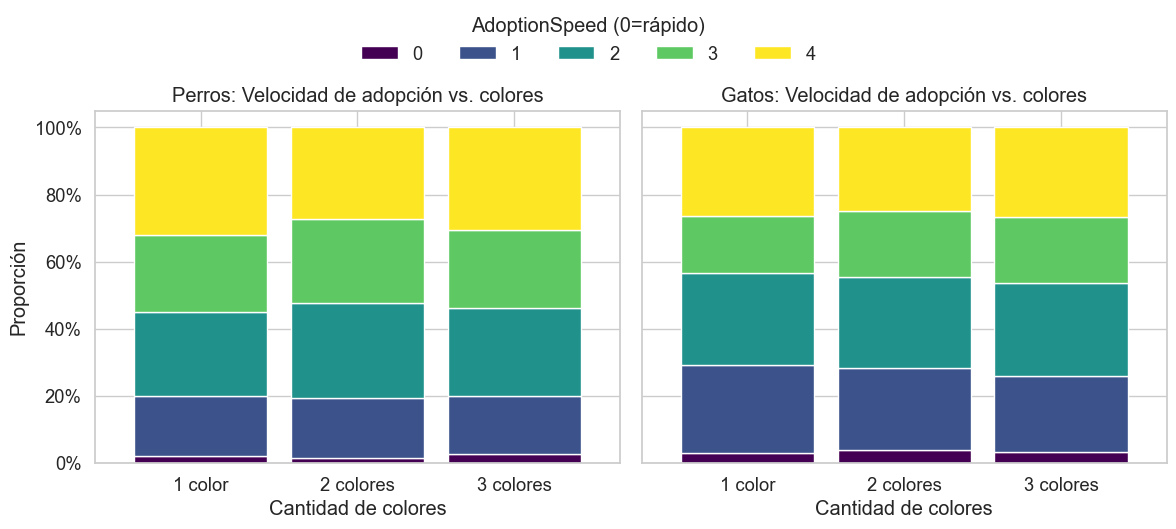

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- 1) # de colores por mascota (vectorizado y robusto) ---
# Cuenta cuántas columnas Color{1,2,3} son != 0
df["Color_comb"] = df[["Color1", "Color2", "Color3"]].ne(0).sum(axis=1).clip(upper=3).astype(int)

# Split por especie
df_dog = df[df["Type"] == "Dog"].copy()
df_cat = df[df["Type"] == "Cat"].copy()

order_speed  = [0, 1, 2, 3, 4]   # 0 = adopción más rápida
order_colors = [1, 2, 3]         # 1,2,3 colores

def props_by_colors(dfi):
    ct = (pd.crosstab(dfi["Color_comb"], dfi["AdoptionSpeed"])
            .reindex(index=order_colors, columns=order_speed, fill_value=0))
    props = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return ct, props

ct_dog, props_dog = props_by_colors(df_dog)
ct_cat, props_cat = props_by_colors(df_cat)

# --- 2) Plot lado a lado (100% apilado) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Perros
props_dog.plot(kind='bar', stacked=True, ax=axes[0], width=0.85, edgecolor='white', colormap='viridis')
axes[0].set_title('Perros: Velocidad de adopción vs. colores')
axes[0].set_xlabel('Cantidad de colores')
axes[0].set_ylabel('Proporción')
axes[0].set_xticklabels(['1 color', '2 colores', '3 colores'], rotation=0)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend_.remove()

# Gatos
props_cat.plot(kind='bar', stacked=True, ax=axes[1], width=0.85, edgecolor='white', colormap='viridis')
axes[1].set_title('Gatos: Velocidad de adopción vs. colores')
axes[1].set_xlabel('Cantidad de colores')
axes[1].set_ylabel('')
axes[1].set_xticklabels(['1 color', '2 colores', '3 colores'], rotation=0)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend_.remove()

# Leyenda común arriba
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title='AdoptionSpeed (0=rápido)', loc='upper center',
           ncol=5, frameon=False, bbox_to_anchor=(0.5, 1.08))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()




No se observa una tendencia clara entre la combinación de colores y la velocidad de adopción.

### 2.7 Análisis según Género

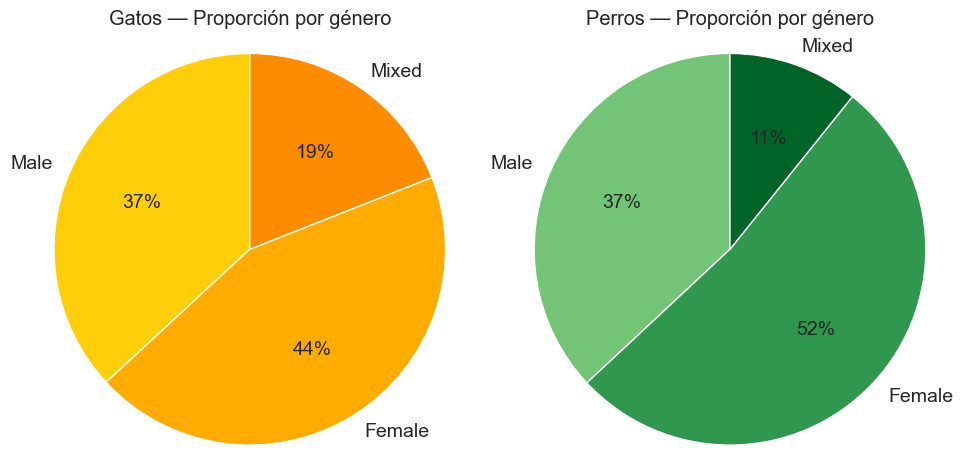

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Mapeo y orden de categorías ---
gender_map   = {1: "Male", 2: "Female", 3: "Mixed"}
order_gender = ["Male", "Female", "Mixed"]

df2 = df.copy()

# Normalizar Gender
df2["Gender"] = (
    pd.to_numeric(df2["Gender"], errors="coerce")
      .map(gender_map)
      .fillna(df2["Gender"])
)
df2 = df2.dropna(subset=["Gender", "Type"])
df2["Gender"] = pd.Categorical(df2["Gender"], categories=order_gender, ordered=True)

# Conteos por género
def counts_by_gender(dfi):
    return (
        dfi["Gender"]
        .value_counts()
        .reindex(order_gender, fill_value=0)
    )

counts_cat = counts_by_gender(df2[df2["Type"] == "Cat"])
counts_dog = counts_by_gender(df2[df2["Type"] == "Dog"])

# Paletas
colors_cat = plt.get_cmap("Wistia")(np.linspace(0.4, 0.9, len(counts_cat)))
colors_dog = plt.get_cmap("Greens")(np.linspace(0.5, 0.9, len(counts_dog)))

# --- Figura con 2 tortas ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Gatos
axes[0].pie(
    counts_cat.values,
    labels=counts_cat.index,
    colors=colors_cat,
    autopct=lambda p: f"{p:.0f}%",
    startangle=90,
    wedgeprops=dict(edgecolor="white"),
    textprops={"fontsize": 14}
)
axes[0].set_title("Gatos — Proporción por género")
axes[0].axis("equal")

# Perros
axes[1].pie(
    counts_dog.values,
    labels=counts_dog.index,
    colors=colors_dog,
    autopct=lambda p: f"{p:.0f}%",
    startangle=90,
    wedgeprops=dict(edgecolor="white"),
    textprops={"fontsize": 14}
)
axes[1].set_title("Perros — Proporción por género")
axes[1].axis("equal")

plt.tight_layout()
plt.show()


C:\Users\josek\AppData\Local\Temp\ipykernel_9620\2245792012.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Gender", "AdoptionSpeed"])
C:\Users\josek\AppData\Local\Temp\ipykernel_9620\2245792012.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Gender", "AdoptionSpeed"])


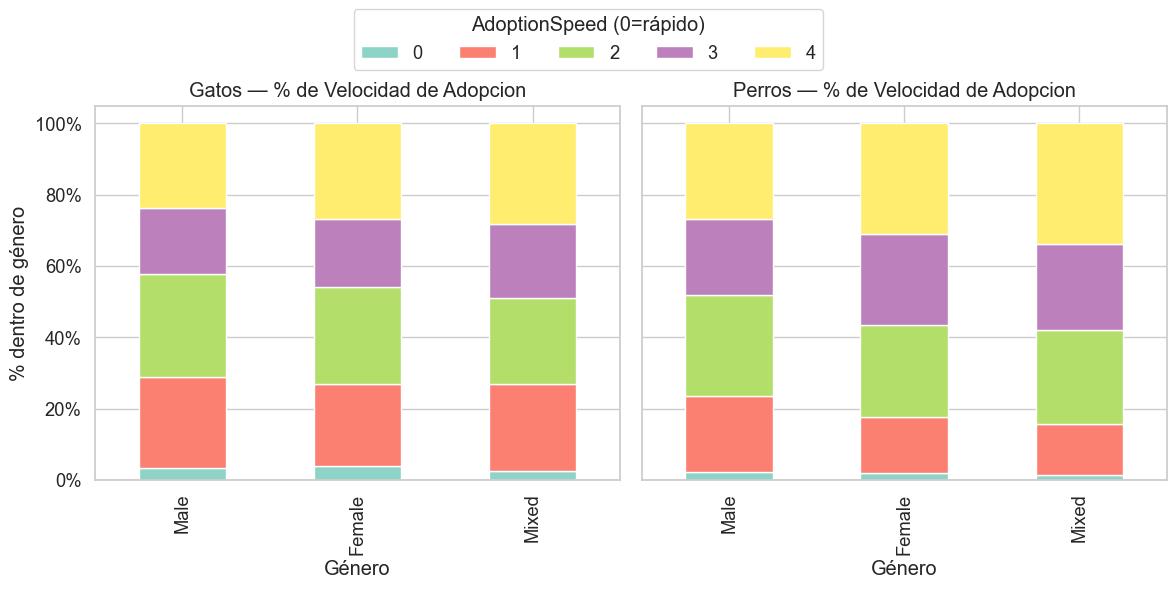

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- Configuración de categorías ---
gender_map   = {1: "Male", 2: "Female", 3: "Mixed"}
order_gender = ["Male", "Female", "Mixed"]
order_speed  = [0, 1, 2, 3, 4]  # 0 = más rápido

# --- Copia y limpieza mínima ---
dfg = df.copy()

# Mapear Gender a texto (si viene como 1/2/3)
dfg["Gender"] = pd.to_numeric(dfg["Gender"], errors="coerce").map(gender_map).fillna(dfg["Gender"])
dfg["Gender"] = pd.Categorical(dfg["Gender"], categories=order_gender, ordered=True)

# Asegurar AdoptionSpeed numérica para reindexar columnas
dfg["AdoptionSpeed"] = pd.to_numeric(dfg["AdoptionSpeed"], errors="coerce")

# Splits por especie
df_cat = dfg[dfg["Type"] == "Cat"].copy()
df_dog = dfg[dfg["Type"] == "Dog"].copy()

def prop_table(data):
    # Tabla de conteos Gender x AdoptionSpeed
    counts = (
        data.groupby(["Gender", "AdoptionSpeed"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=order_speed, fill_value=0)      # ordenar columnas 0..4
            .reindex(index=order_gender, fill_value=0)       # ordenar filas por género
    )
    # Proporciones por género (fila)
    props = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return props

# Tablas de proporciones
prop_cat = prop_table(df_cat)
prop_dog = prop_table(df_dog)

# --- Graficar lado a lado con leyenda única ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Gatos
prop_cat.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set3")
axes[0].set_title("Gatos — % de Velocidad de Adopcion")
axes[0].set_xlabel("Género")
axes[0].set_ylabel("% dentro de género")
axes[0].legend_.remove() 

# Perros
prop_dog.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3")
axes[1].set_title("Perros — % de Velocidad de Adopcion")
axes[1].set_xlabel("Género")
axes[1].set_ylabel("")
axes[1].legend_.remove() 

# Leyenda común arriba (AdoptionSpeed)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="AdoptionSpeed (0=rápido)", loc="upper center", ncol=5)

# Formato de eje Y en %
for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


Composición por género

- Gatos: aprox. Hembra 44%, Macho 37%, Mixto 19%.
Los géneros tienen composiciones muy parecidas; no aparece una relación fuerte entre género y velocidad de adopción.

- Perros: aprox. Hembra 52%, Macho 37%, Mixto 11%.
En perros los machos se adoptan más rápido (mayor proporción en 0–1), mientras que las hembras concentran más adopciones lentas (mayor proporción en 3–4).

### 2.8 Segun estado de salud general

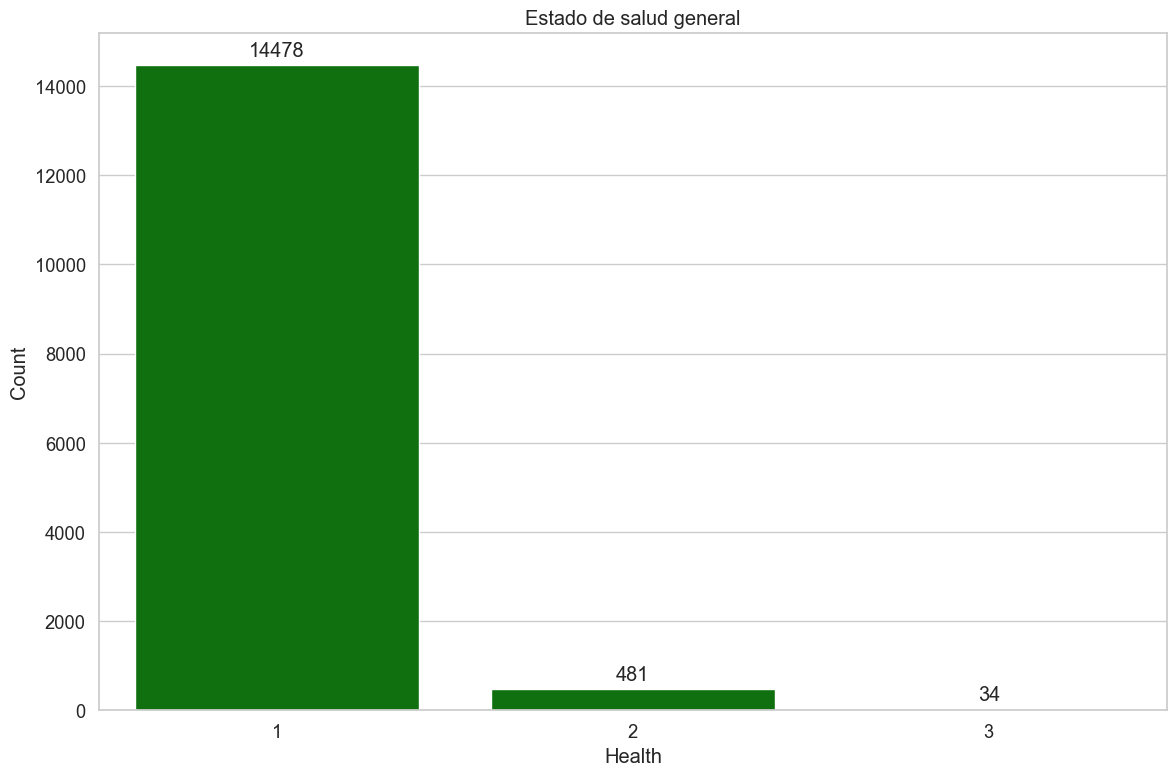

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar chart de conteos (color verde)
ax = sns.countplot(data=df, x="Health", color="green",
                   order=sorted(df["Health"].dropna().unique()))

ax.set_xlabel("Health")
ax.set_ylabel("Count")
ax.set_title("Estado de salud general")

# Etiquetas con el conteo arriba de cada barra
ax.bar_label(ax.containers[0], fmt="%d", padding=3)

plt.tight_layout()
plt.show()


C:\Users\josek\AppData\Local\Temp\ipykernel_9620\252993800.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Health", "AdoptionSpeed"])
C:\Users\josek\AppData\Local\Temp\ipykernel_9620\252993800.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["Health", "AdoptionSpeed"])


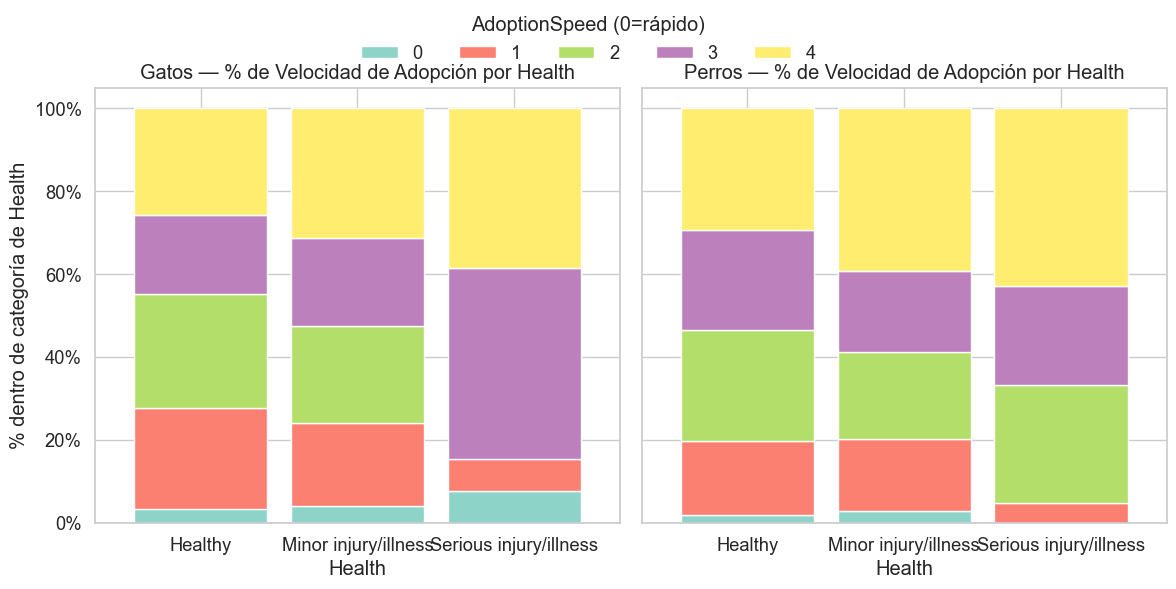

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- Configuración de categorías ---
# Ajustá los textos si tu dataset usa otras descripciones
health_map   = {1: "Healthy", 2: "Minor injury/illness", 3: "Serious injury/illness"}
order_health = ["Healthy", "Minor injury/illness", "Serious injury/illness"]
order_speed  = [0, 1, 2, 3, 4]  # 0 = más rápido

# --- Copia y limpieza mínima ---
dfh = df.copy()

# Mapear Health (si viene como 1/2/3); si ya viene en texto, se respeta
dfh["Health"] = pd.to_numeric(dfh["Health"], errors="coerce").map(health_map).fillna(dfh["Health"])

# Orden de Health dinámico: usamos el deseado si existe, si no, lo que haya en datos
present_health = [h for h in order_health if h in dfh["Health"].astype(str).unique()]
if not present_health:
    present_health = [str(h) for h in pd.Series(dfh["Health"]).dropna().unique()]

dfh["Health"] = pd.Categorical(dfh["Health"], categories=present_health, ordered=True)

# Asegurar AdoptionSpeed numérica
dfh["AdoptionSpeed"] = pd.to_numeric(dfh["AdoptionSpeed"], errors="coerce")

# Splits por especie
df_cat = dfh[dfh["Type"] == "Cat"].copy()
df_dog = dfh[dfh["Type"] == "Dog"].copy()

def prop_table(data):
    # Tabla Health x AdoptionSpeed
    counts = (
        data.groupby(["Health", "AdoptionSpeed"])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=order_speed, fill_value=0)      # columnas 0..4
            .reindex(index=present_health, fill_value=0)     # filas según orden de Health
    )
    # Proporciones por Health (cada fila = 100%)
    props = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return props

# Tablas de proporciones
prop_cat = prop_table(df_cat)
prop_dog = prop_table(df_dog)

# --- Graficar lado a lado con leyenda única ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Gatos
prop_cat.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set3", width=0.85, edgecolor="white")
axes[0].set_title("Gatos — % de Velocidad de Adopción por Health")
axes[0].set_xlabel("Health")
axes[0].set_ylabel("% dentro de categoría de Health")
axes[0].legend_.remove()
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Perros
prop_dog.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3", width=0.85, edgecolor="white")
axes[1].set_title("Perros — % de Velocidad de Adopción por Health")
axes[1].set_xlabel("Health")
axes[1].set_ylabel("")
axes[1].legend_.remove()
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Leyenda común arriba (AdoptionSpeed)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="AdoptionSpeed (0=rápido)", loc="upper center", ncol=5, frameon=False)

# Eje Y en %
for ax in axes:
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


El 96,6% de las mascotas presenta buen estado de salud; en ambas especies, las saludables tienden a ser adoptadas con mayor rapidez

### 2.9 Vacunación

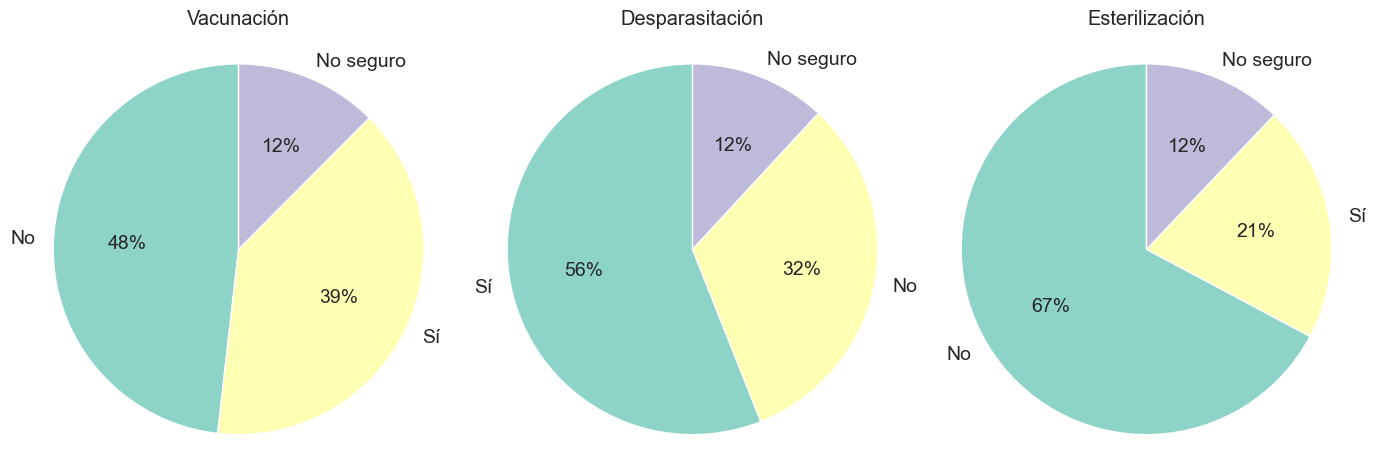

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mapeo opcional (PetFinder): 1=Sí, 2=No, 3=No seguro
code_map = {1: "Sí", 2: "No", 3: "No seguro"}

def prep_counts(series, mapping=None):
    s = series.copy()
    if mapping is not None:
        # Si viene como 1/2/3 (o string "1"/"2"/"3"), mapeamos a texto
        s = pd.to_numeric(s, errors="coerce").map(mapping).fillna(series.astype(str))
    return s.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["Vaccinated", "Dewormed", "Sterilized"],
    ["Vacunación", "Desparasitación", "Esterilización"]
):
    counts = prep_counts(df[col], code_map)
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct=lambda p: f"{p:.0f}%",
        startangle=90,
        wedgeprops=dict(edgecolor="white"),
        textprops={"fontsize": 14}
    )
    ax.set_title(title)
    ax.axis("equal")

plt.tight_layout()
plt.show()


La mayoría de las mascosta parece presentar un patrón homogéneo de cuidados (vacunación, desparasitación y esterilización)

C:\Users\josek\AppData\Local\Temp\ipykernel_9620\3020822823.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (dfin.groupby(["care_score", "AdoptionSpeed"])
C:\Users\josek\AppData\Local\Temp\ipykernel_9620\3020822823.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (dfin.groupby(["care_score", "AdoptionSpeed"])
C:\Users\josek\AppData\Local\Temp\ipykernel_9620\3020822823.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sil

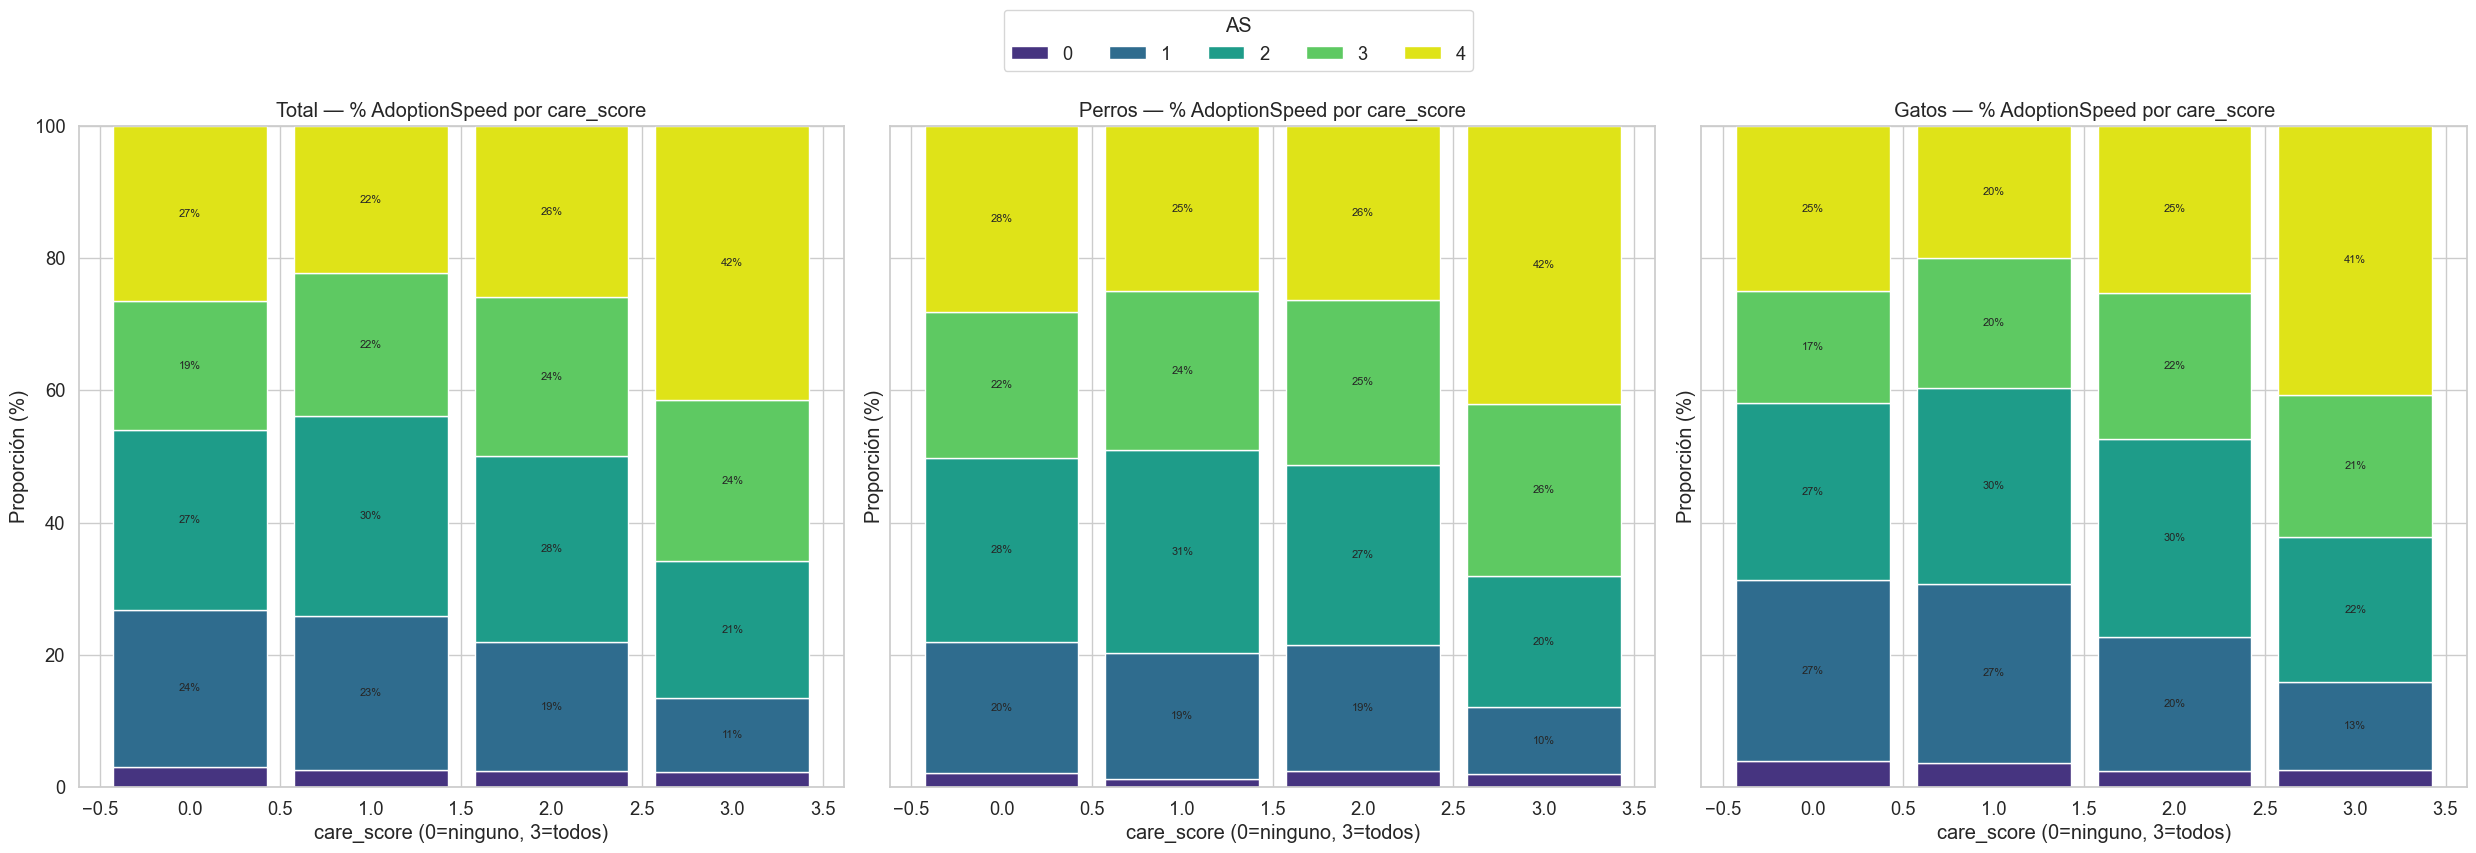

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Construir care_score (0..3) 
# 1=Sí, 2=No, 3=No seguro  → aquí tratamos 3 como NO (0). 
cols = ["Vaccinated", "Dewormed", "Sterilized"]
map_yes = {1: 1, 2: 0, 3: 0}

df2 = df.copy()
for c in cols:
    df2[c + "_yes"] = pd.to_numeric(df2[c], errors="coerce").map(map_yes)

df2["care_score"] = df2[[c + "_yes" for c in cols]].sum(axis=1)

# Aseguramos categorías/órdenes
order_speed = [0, 1, 2, 3, 4]
order_score = [0, 1, 2, 3]
df2 = df2.dropna(subset=["AdoptionSpeed", "care_score"])
df2["AdoptionSpeed"] = pd.Categorical(df2["AdoptionSpeed"], categories=order_speed, ordered=True)
df2["care_score"]    = pd.Categorical(df2["care_score"],    categories=order_score, ordered=True)

# ===== 2) Helper para tabla de % por care_score =====
def prep_percent_by_score(dfin):
    tab = (dfin.groupby(["care_score", "AdoptionSpeed"])
               .size()
               .unstack(fill_value=0)
               .reindex(index=order_score, columns=order_speed, fill_value=0))
    perc = tab.div(tab.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
    return perc

# ===== 3) Helper para graficar 100% apilado con etiquetas =====
colors_speed = plt.get_cmap("viridis")(np.linspace(0.15, 0.95, len(order_speed)))

def plot_100_stacked(ax, perc, title):
    bottom = np.zeros(len(perc.index))
    for j, sp in enumerate(order_speed):
        vals = perc[sp].values
        ax.bar(perc.index, vals, bottom=bottom, color=colors_speed[j], label=str(sp), width=0.85)
        # Etiquetas de % sólo si el segmento ≥ 8%
        for i, v in enumerate(vals):
            if v >= 8:
                ax.text(i, bottom[i] + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=8)
        bottom += vals
    ax.set_title(title)
    ax.set_xlabel("care_score (0=ninguno, 3=todos)")
    ax.set_ylabel("Proporción (%)")
    ax.set_ylim(0, 100)

# ===== 4) Tablas y gráfico (Total / Perros / Gatos) =====
perc_all = prep_percent_by_score(df2)
perc_dog = prep_percent_by_score(df2[df2["Type"] == "Dog"])
perc_cat = prep_percent_by_score(df2[df2["Type"] == "Cat"])

fig, axes = plt.subplots(1, 3, figsize=(25, 8), sharey=True)

plot_100_stacked(axes[0], perc_all, "Total — % AdoptionSpeed por care_score")
plot_100_stacked(axes[1], perc_dog, "Perros — % AdoptionSpeed por care_score")
plot_100_stacked(axes[2], perc_cat, "Gatos — % AdoptionSpeed por care_score")

# Leyenda común
handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, title="AS", loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.08))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


Observamos que la gran mayoría de las mascotas está saludable y que las personas tienden a preferir la adopción de aquellas que ya están vacunadas, desparasitadas y esterilizadas.

### Contenido multimedia

In [57]:
def content_checker(row):
    cant = row.VideoAmt + row.PhotoAmt
    if cant > 0:
        return 1
    else:
        return 0
        
df["Content"] = df.apply(content_checker, axis=1)

df_dog = df[df['Type'] == "Dog"]
df_cat = df[df['Type'] == "Cat"]

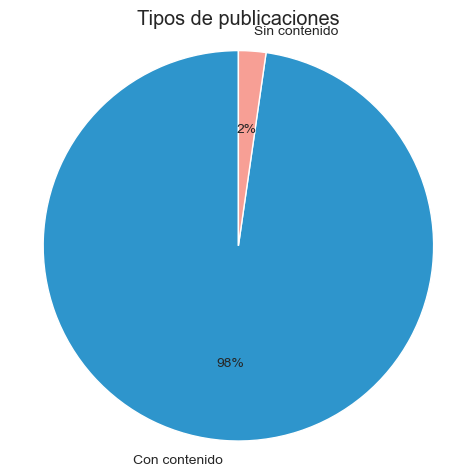

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Ordenamos para que primero aparezca "Con contenido" (1) y luego "Sin contenido" (0)
counts = df["Content"].value_counts().reindex([1, 0], fill_value=0)

labels = ["Con contenido", "Sin contenido"]
sizes = counts.values

# Colores personalizados (verde = sí, rojo = no)
colors = ["#2e95cc", "#f79f95"]

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=lambda p: f"{p:.0f}%",
    startangle=90,
    wedgeprops=dict(edgecolor="white"),
    textprops={"fontsize": 10}
)
ax.set_title("Tipos de publicaciones")
ax.axis("equal")
plt.tight_layout()
plt.show()


C:\Users\josek\AppData\Local\Temp\ipykernel_9620\733301182.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (d.groupby(["ContentLabel", "AdoptionSpeed"])
C:\Users\josek\AppData\Local\Temp\ipykernel_9620\733301182.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (d.groupby(["ContentLabel", "AdoptionSpeed"])


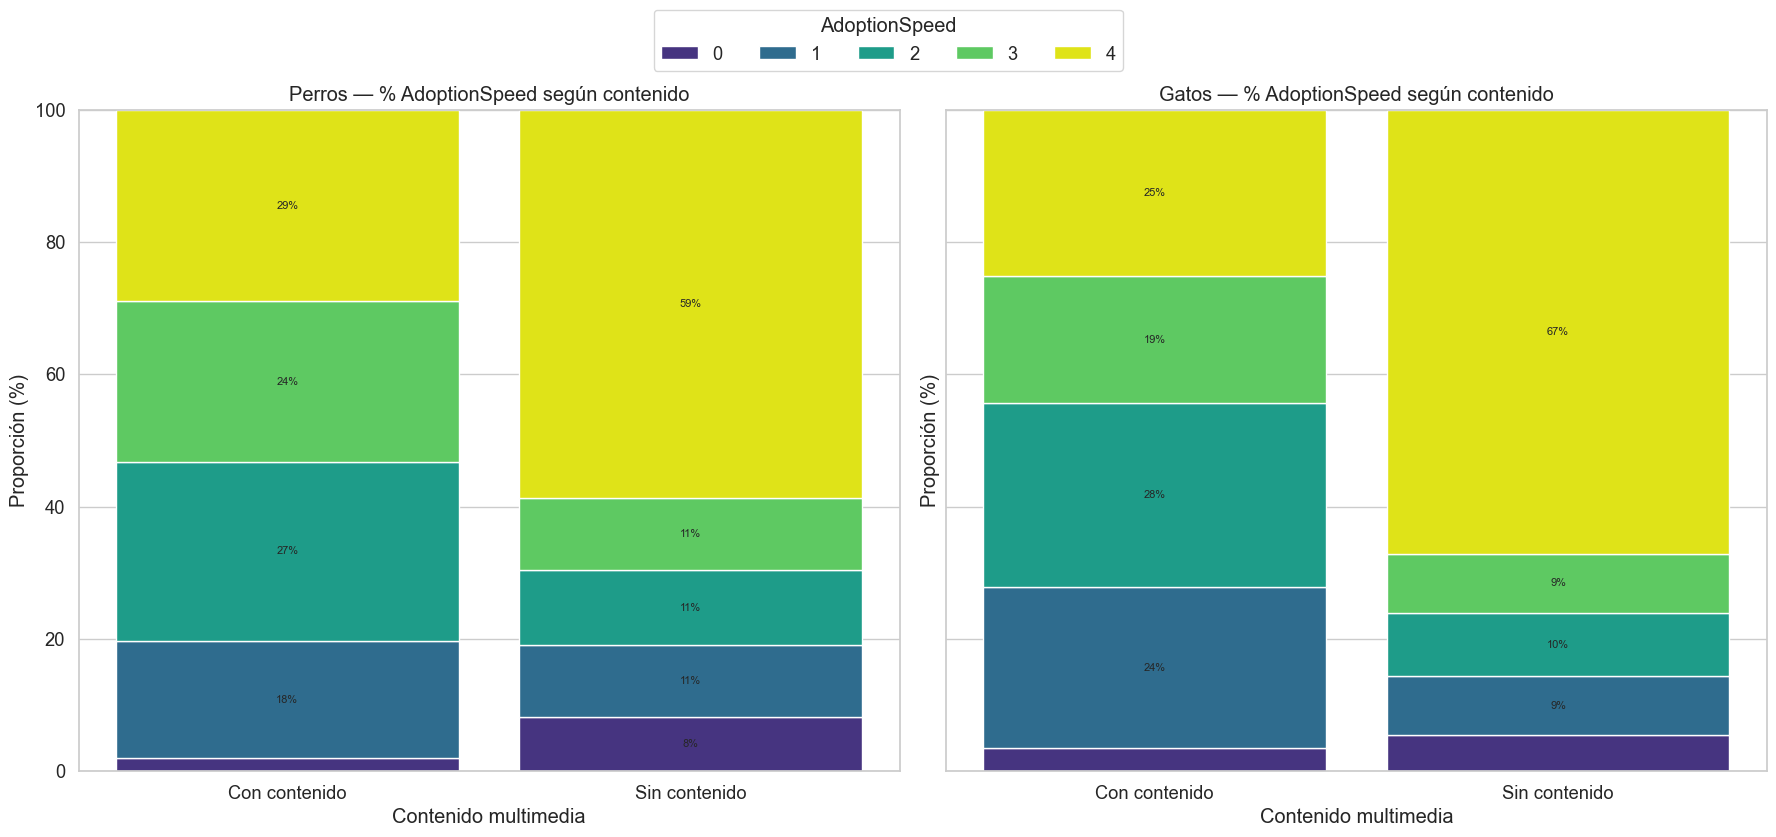

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- Config -----
order_speed = [0, 1, 2, 3, 4]
content_map = {1: "Con contenido", 0: "Sin contenido"}
order_content = ["Con contenido", "Sin contenido"]
colors_speed = plt.get_cmap("viridis")(np.linspace(0.15, 0.95, len(order_speed)))

def perc_by_content(dfi):
    d = dfi.copy()
    d["Content"] = pd.to_numeric(d["Content"], errors="coerce")
    d = d.dropna(subset=["Content", "AdoptionSpeed"])
    d["AdoptionSpeed"] = pd.Categorical(d["AdoptionSpeed"], categories=order_speed, ordered=True)
    d["ContentLabel"] = d["Content"].map(content_map)
    tab = (d.groupby(["ContentLabel", "AdoptionSpeed"])
             .size()
             .unstack(fill_value=0)
             .reindex(index=order_content, columns=order_speed, fill_value=0))
    perc = tab.div(tab.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
    return perc

def plot_100_stacked(ax, perc, title):
    bottom = np.zeros(len(perc.index))
    for j, sp in enumerate(order_speed):
        vals = perc[sp].values
        ax.bar(perc.index, vals, bottom=bottom, color=colors_speed[j], label=str(sp), width=0.85)
        # Etiquetas % (solo si el segmento es suficientemente grande)
        for i, v in enumerate(vals):
            if v >= 8:
                ax.text(i, bottom[i] + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=8)
        bottom += vals
    ax.set_title(title)
    ax.set_xlabel("Contenido multimedia")
    ax.set_ylabel("Proporción (%)")
    ax.set_ylim(0, 100)

# ----- Data -----
perc_dog = perc_by_content(df_dog)
perc_cat = perc_by_content(df_cat)

# ----- Plot: 1 fila, 2 gráficos (Dog | Cat) -----
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

plot_100_stacked(axes[0], perc_dog, "Perros — % AdoptionSpeed según contenido")
plot_100_stacked(axes[1], perc_cat, "Gatos — % AdoptionSpeed según contenido")

# Leyenda común
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="AdoptionSpeed", loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.06))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


Según lo observado publicar con contenido se asocia a adopciones más rápidas, y el efecto parece más fuerte en gatos.

#### Videos

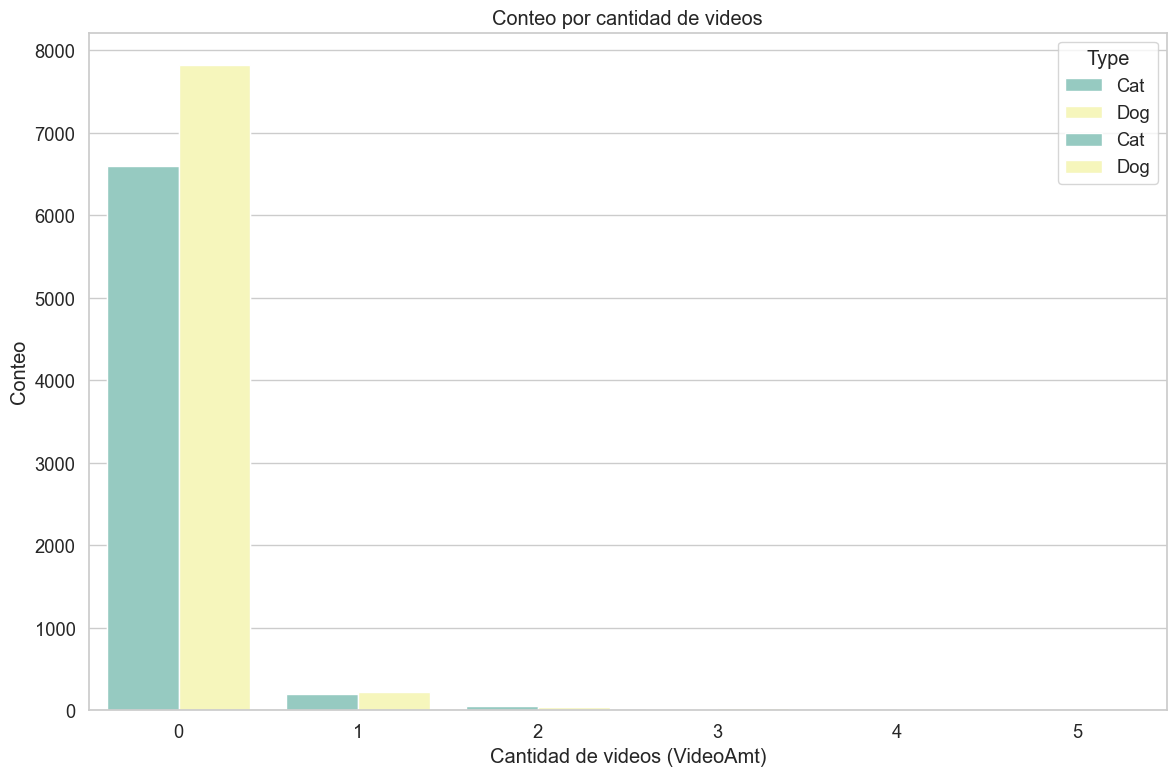

In [60]:
# Ahora analizamos cantidad de videos

sns.countplot(data=df, x='VideoAmt', hue='Type')
plt.title('Conteo por cantidad de videos')
plt.xlabel('Cantidad de videos (VideoAmt)')
plt.ylabel('Conteo')
plt.xticks(range(0, 6)) 
sns.countplot(data=df, x='VideoAmt', hue='Type', order=range(0, 6))

plt.tight_layout()
plt.show()



Se evidencia una baja presencia de videos en las publicaciones

#### Fotos

In [61]:
def photo_category(row):
    '''
    Categorias:
    0 -> sin foto
    1 -> de 1 a 5
    2 -> de 6 a 10
    3 -> más de 10
    '''
    if row.PhotoAmt < 1:
        return 0
    elif row.PhotoAmt < 6:
        return 1
    elif row.PhotoAmt < 11:
        return 2
    else:
        return 3
        
df["PhotoCategory"] = df.apply(photo_category, axis=1)

df_dog = df[df['Type'] == "Dog"]
df_cat = df[df['Type'] == "Cat"]

C:\Users\josek\AppData\Local\Temp\ipykernel_9620\322009044.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (d.groupby(["PhotoCategory", "AdoptionSpeed"])
C:\Users\josek\AppData\Local\Temp\ipykernel_9620\322009044.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = (d.groupby(["PhotoCategory", "AdoptionSpeed"])


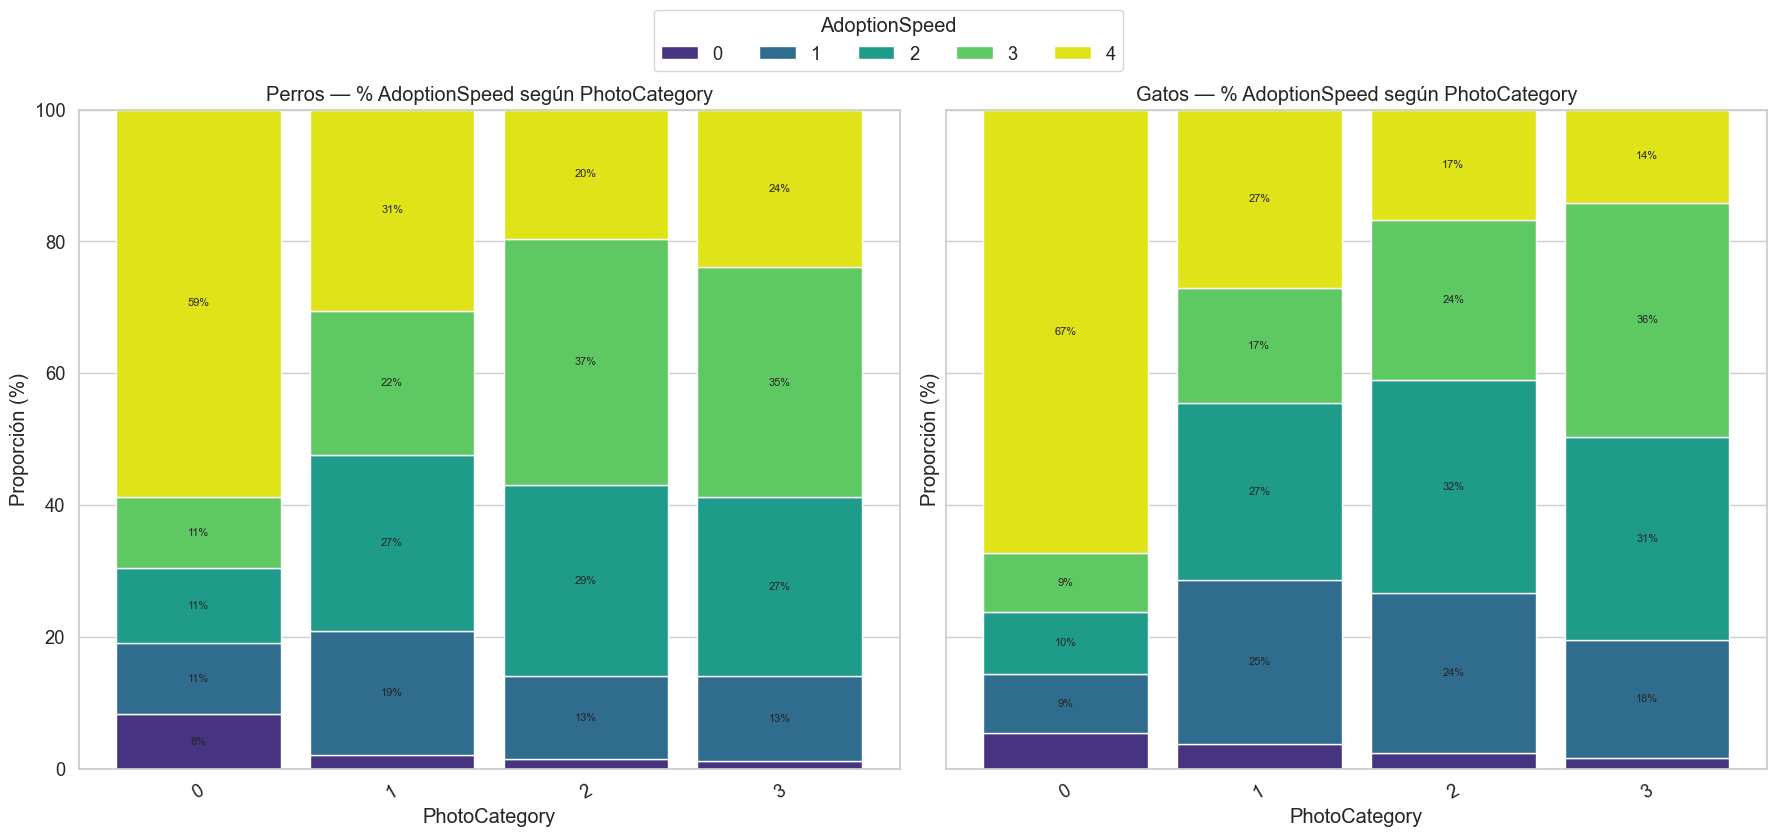

In [62]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- Config -----
order_speed = [0, 1, 2, 3, 4]
colors_speed = plt.get_cmap("viridis")(np.linspace(0.15, 0.95, len(order_speed)))

def natural_order_categories(vals):
    """Ordena categorías tipo '0','1','2–3','8+' de forma 'natural'."""
    def key(x):
        s = str(x)
        m = re.match(r"^(\d+)", s)  # primer número al inicio si existe
        return (int(m.group(1)) if m else float('inf'), s)
    return sorted(pd.Series(vals).dropna().unique(), key=key)

def perc_by_photo_category(dfi):
    d = dfi.copy()
    d = d.dropna(subset=["PhotoCategory", "AdoptionSpeed"])
    # Orden "natural" para PhotoCategory
    order_photo = natural_order_categories(d["PhotoCategory"])
    # Asegurar órdenes
    d["PhotoCategory"] = pd.Categorical(d["PhotoCategory"], categories=order_photo, ordered=True)
    d["AdoptionSpeed"] = pd.Categorical(d["AdoptionSpeed"], categories=order_speed, ordered=True)
    # Tabla de conteos y % por fila (cada categoría de foto suma 100%)
    tab = (d.groupby(["PhotoCategory", "AdoptionSpeed"])
             .size()
             .unstack(fill_value=0)
             .reindex(index=order_photo, columns=order_speed, fill_value=0))
    perc = tab.div(tab.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100
    return perc

def plot_100_stacked(ax, perc, title):
    bottom = np.zeros(len(perc.index))
    for j, sp in enumerate(order_speed):
        vals = perc[sp].values
        ax.bar(perc.index.astype(str), vals, bottom=bottom, color=colors_speed[j], label=str(sp), width=0.85)
        # Etiquetas % (mostrar solo segmentos >= 8% para no saturar)
        for i, v in enumerate(vals):
            if v >= 8:
                ax.text(i, bottom[i] + v/2, f"{v:.0f}%", ha="center", va="center", fontsize=8)
        bottom += vals
    ax.set_title(title)
    ax.set_xlabel("PhotoCategory")
    ax.set_ylabel("Proporción (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=30)

# ----- Data -----
perc_dog = perc_by_photo_category(df_dog)
perc_cat = perc_by_photo_category(df_cat)

# ----- Plot: 1 fila, 2 gráficos (Dog | Cat) -----
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

plot_100_stacked(axes[0], perc_dog, "Perros — % AdoptionSpeed según PhotoCategory")
plot_100_stacked(axes[1], perc_cat, "Gatos — % AdoptionSpeed según PhotoCategory")

# Leyenda común
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, title="AdoptionSpeed", loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.06))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


Se observa que sin foto, la adopción es algo más lenta: sube la proporción en la categoría 4; con foto, esa categoría baja.

### Conclusiones

* En este dataset (54% perros, 46% gatos) predominan mascotas muy jóvenes (2–3 meses) y la adopción inmediata es rara, aunque aproximandamente la mitad se concreta en el primer mes.
* El Fee no muestra relación consistente con la rapidez en la adopción.
* La pureza de raza acelera la adopción en perros y es casi neutra en gatos. 
* En perros, los machos tienden a adoptarse antes que las hembras, algo no tan claro en gatos. 
* La mayoría de las mascotas están “saludable”, y si estan vacunados, esterilizados o desparacitados se adoptan mas rapidos
* En cuando al contenido multimedia, la presencia de fotos o video puede afectar la velocidad de adopciones , especialmente en gatos.